In [2]:
import pandas as pd
import numpy as nb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" all import sucessfully")


 all import sucessfully


In [3]:
import urllib.request
import os

# Create directory if not exists
os.makedirs('../data/raw', exist_ok=True)

print("Downloading Amazon Electronics dataset...")
print("This may take 2-3 minutes depending on connection...")

url = "https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/ratings_Electronics.csv"
save_path = "../data/raw/ratings_Electronics.csv"

# Download with progress
urllib.request.urlretrieve(url, save_path)

# Check file size
size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"✓ Downloaded successfully!")
print(f"✓ File size: {size_mb:.1f} MB")

This may take 2-3 minutes depending on connection...


✓ Downloaded successfully!
✓ File size: 304.0 MB


In [4]:
df = pd.read_csv('../data/raw/ratings_Electronics.csv',
                 header=None,
                 names=['user_id', 'item_id', 'rating', 'timestamp'])

print(f"✓ Data loaded successfully")
print(f"\nFirst 5 rows:")
df.head()

✓ Data loaded successfully

First 5 rows:


,user_id,item_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [5]:
print("=" * 40)
print("   DATA QUALITY REPORT")
print("=" * 40)
print(f"Total interactions : {len(df):,}")
print(f"Unique users       : {df['user_id'].nunique():,}")
print(f"Unique items       : {df['item_id'].nunique():,}")
print(f"Rating range       : {df['rating'].min()} - {df['rating'].max()}")
print(f"Missing values     : {df.isnull().sum().sum()}")
print(f"Duplicate rows     : {df.duplicated().sum():,}")
print("=" * 40)
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())

   DATA QUALITY REPORT
Total interactions : 7,824,482
Unique users       : 4,201,696
Unique items       : 476,002
Rating range       : 1.0 - 5.0
Missing values     : 0
Duplicate rows     : 0

Rating distribution:
rating
1.0     901765
2.0     456322
3.0     633073
4.0    1485781
5.0    4347541
Name: count, dtype: int64


In [6]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_interactions = len(df)

sparsity = 1 - (n_interactions / (n_users * n_items))

print("=" * 40)
print("   SPARSITY ANALYSIS")
print("=" * 40)
print(f"Total users        : {n_users:,}")
print(f"Total items        : {n_items:,}")
print(f"Total interactions : {n_interactions:,}")
print(f"Matrix sparsity    : {sparsity:.4%}")
print("=" * 40)

if sparsity > 0.99:
    print("✓ Sparsity > 99% — normal for recommendation systems")
    print("✓ ALS collaborative filtering is the right choice here")

   SPARSITY ANALYSIS
Total users        : 4,201,696
Total items        : 476,002
Total interactions : 7,824,482
Matrix sparsity    : 99.9996%
✓ Sparsity > 99% — normal for recommendation systems
✓ ALS collaborative filtering is the right choice here


In [7]:
user_activity = df.groupby('user_id').size()

print("=" * 40)
print("   USER ACTIVITY ANALYSIS")
print("=" * 40)
print(f"Users with 1 rating    : {(user_activity == 1).sum():,} ({(user_activity == 1).mean():.1%})")
print(f"Users with < 3 ratings : {(user_activity < 3).sum():,} ({(user_activity < 3).mean():.1%})")
print(f"Users with < 5 ratings : {(user_activity < 5).sum():,} ({(user_activity < 5).mean():.1%})")
print(f"Users with >= 5 ratings: {(user_activity >= 5).sum():,} ({(user_activity >= 5).mean():.1%})")
print(f"\nMedian ratings/user    : {user_activity.median()}")
print(f"Mean ratings/user      : {user_activity.mean():.2f}")
print(f"Max ratings/user       : {user_activity.max()}")
print("=" * 40)

cold_start_pct = (user_activity < 3).mean()
print(f"\n⚠ Cold start affects {cold_start_pct:.1%} of users")
print(f"→ We MUST build a fallback for these users")
print(f"→ Cold start threshold set at: < 3 interactions")

   USER ACTIVITY ANALYSIS
Users with 1 rating    : 2,881,832 (68.6%)
Users with < 3 ratings : 3,550,016 (84.5%)
Users with < 5 ratings : 3,947,632 (94.0%)
Users with >= 5 ratings: 254,064 (6.0%)

Median ratings/user    : 1.0
Mean ratings/user      : 1.86
Max ratings/user       : 520

⚠ Cold start affects 84.5% of users
→ We MUST build a fallback for these users
→ Cold start threshold set at: < 3 interactions


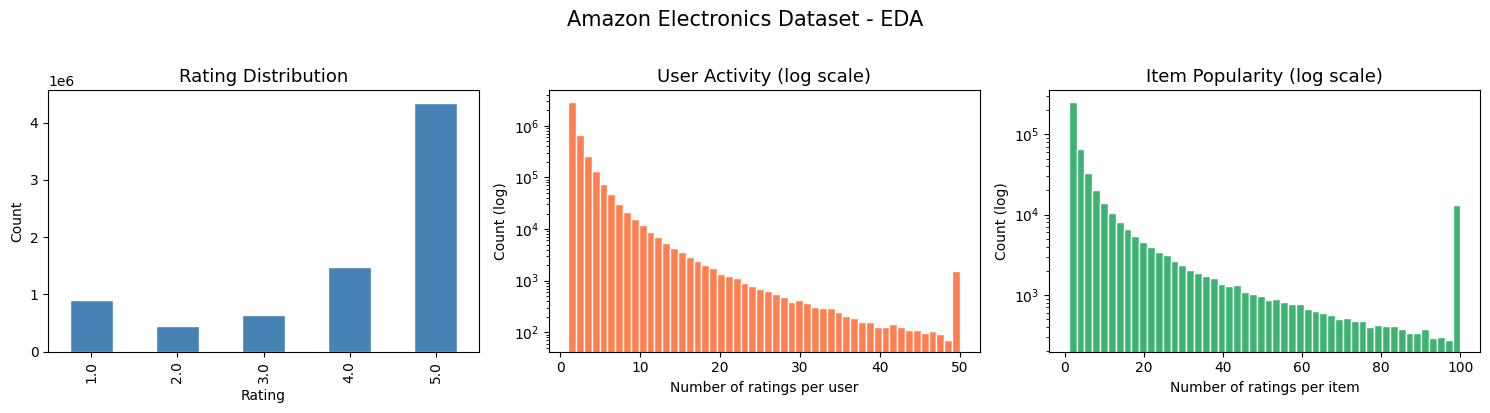

✓ Plot saved to data/processed/eda_distributions.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 - Rating distribution
df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution', fontsize=13)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Plot 2 - User activity
user_activity.clip(upper=50).plot(
    kind='hist', bins=50, ax=axes[1],
    color='coral', edgecolor='white', log=True)
axes[1].set_title('User Activity (log scale)', fontsize=13)
axes[1].set_xlabel('Number of ratings per user')
axes[1].set_ylabel('Count (log)')

# Plot 3 - Item popularity
item_popularity = df.groupby('item_id').size()
item_popularity.clip(upper=100).plot(
    kind='hist', bins=50, ax=axes[2],
    color='mediumseagreen', edgecolor='white', log=True)
axes[2].set_title('Item Popularity (log scale)', fontsize=13)
axes[2].set_xlabel('Number of ratings per item')
axes[2].set_ylabel('Count (log)')

plt.suptitle('Amazon Electronics Dataset - EDA', fontsize=15, y=1.02)
plt.tight_layout()

os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Plot saved to data/processed/eda_distributions.png")

In [9]:
# ── Popularity Baseline ──────────────────────────────
top_items = (df.groupby('item_id')
               .agg(
                   rating_count=('rating', 'count'),
                   avg_rating=('rating', 'mean')
               )
               .query('rating_count >= 10')
               .sort_values('rating_count', ascending=False)
               .head(20))

print("=" * 40)
print("   POPULARITY BASELINE (Top 20)")
print("=" * 40)
print(top_items)
top_items.to_csv('../data/processed/popularity_baseline.csv')
print("\n✓ Baseline saved")

# ── Save Clean Data ───────────────────────────────────
active_users = user_activity[user_activity >= 3].index
df_filtered = df[df['user_id'].isin(active_users)].copy()

print(f"\n{'=' * 40}")
print(f"   CLEAN DATA SUMMARY")
print(f"{'=' * 40}")
print(f"Original interactions : {len(df):,}")
print(f"Filtered interactions : {len(df_filtered):,}")
print(f"Users kept            : {df_filtered['user_id'].nunique():,}")
print(f"Items kept            : {df_filtered['item_id'].nunique():,}")
print(f"Data reduction        : {(1 - len(df_filtered)/len(df)):.1%}")

df_filtered.to_csv('../data/processed/ratings_clean.csv', index=False)
print(f"\n✓ Clean data saved to data/processed/ratings_clean.csv")

print(f"\n{'=' * 40}")
print(f"   ✓ WEEK 1 COMPLETE!")
print(f"{'=' * 40}")
print(f"Next step → Week 2: Train ALS model")

   POPULARITY BASELINE (Top 20)
            rating_count  avg_rating
item_id                             
B0074BW614         18244    4.491504
B00DR0PDNE         16454    3.931020
B007WTAJTO         14172    4.424005
B0019EHU8G         12285    4.754497
B006GWO5WK         12226    4.314657
B003ELYQGG         11617    4.392528
B003ES5ZUU         10276    4.704749
B007R5YDYA          9907    4.690926
B00622AG6S          9823    4.420136
B0002L5R78          9487    4.448614
B008OHNZI0          8966    4.282958
B003LR7ME6          8840    4.508484
B000LRMS66          8715    4.756627
B009SYZ8OC          8370    4.219952
B00BGA9WK2          7561    4.075519
B004QK7HI8          7060    4.013314
B009A5204K          7059    4.073665
B00BGGDVOO          6893    4.369505
B0098F5W0Q          6616    4.263452
B002MAPRYU          6599    3.913623

✓ Baseline saved

   CLEAN DATA SUMMARY
Original interactions : 7,824,482
Filtered interactions : 3,606,282
Users kept            : 651,680
Items kept   